In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('Coffee Shop Sales.csv')

In [4]:
print(f"Dataset Shape: {df.shape}")
print("\nColumn Data Types:")
print(df.dtypes)
print("-" * 30)

Dataset Shape: (149116, 11)

Column Data Types:
transaction_id        int64
transaction_date        str
transaction_time        str
transaction_qty       int64
store_id              int64
store_location          str
product_id            int64
unit_price          float64
product_category        str
product_type            str
product_detail          str
dtype: object
------------------------------


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")
print("-" * 30)

Missing values per column:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

Number of duplicate rows: 0
------------------------------


In [8]:
# Focus on transaction quantity and unit price
print(df[['transaction_qty', 'unit_price']].describe())
print("-" * 30)

       transaction_qty     unit_price
count    149116.000000  149116.000000
mean          1.438276       3.382219
std           0.542509       2.658723
min           1.000000       0.800000
25%           1.000000       2.500000
50%           1.000000       3.000000
75%           2.000000       3.750000
max           8.000000      45.000000
------------------------------


In [10]:
# Check unique counts for locations and product types
print(df.describe(include='object'))
print("-" * 30)

       transaction_date transaction_time  store_location product_category  \
count            149116           149116          149116           149116   
unique              181            25762               3                9   
top           6/19/2023          9:31:15  Hell's Kitchen           Coffee   
freq               1343               41           50735            58416   

           product_type       product_detail  
count            149116               149116  
unique               29                   80  
top     Brewed Chai tea  Chocolate Croissant  
freq              17183                 3076  
------------------------------


C:\Users\mark ando\AppData\Local\Temp\ipykernel_22556\752680588.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


In [12]:
print("Unique categories of products:", df['product_category'].unique())
print("\nStore Locations involved:", df['store_location'].unique())
print("-" * 30)

Unique categories of products: <StringArray>
[            'Coffee',                'Tea', 'Drinking Chocolate',
             'Bakery',           'Flavours',          'Loose Tea',
       'Coffee beans', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

Store Locations involved: <StringArray>
['Lower Manhattan', 'Hell's Kitchen', 'Astoria']
Length: 3, dtype: str
------------------------------


In [17]:
Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['unit_price'] < lower_bound) | (df['unit_price'] > upper_bound)]
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Number of price outliers detected: {len(outliers)}")
print("-" * 30)

Lower Bound: 0.625, Upper Bound: 5.625
Number of price outliers detected: 4212
------------------------------


In [18]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

print("New Date Type:", df['transaction_date'].dtype)
print("First 5 formatted dates:")
print(df['transaction_date'].head())
print("-" * 30)

New Date Type: datetime64[us]
First 5 formatted dates:
0   2023-01-01
1   2023-01-01
2   2023-01-01
3   2023-01-01
4   2023-01-01
Name: transaction_date, dtype: datetime64[us]
------------------------------


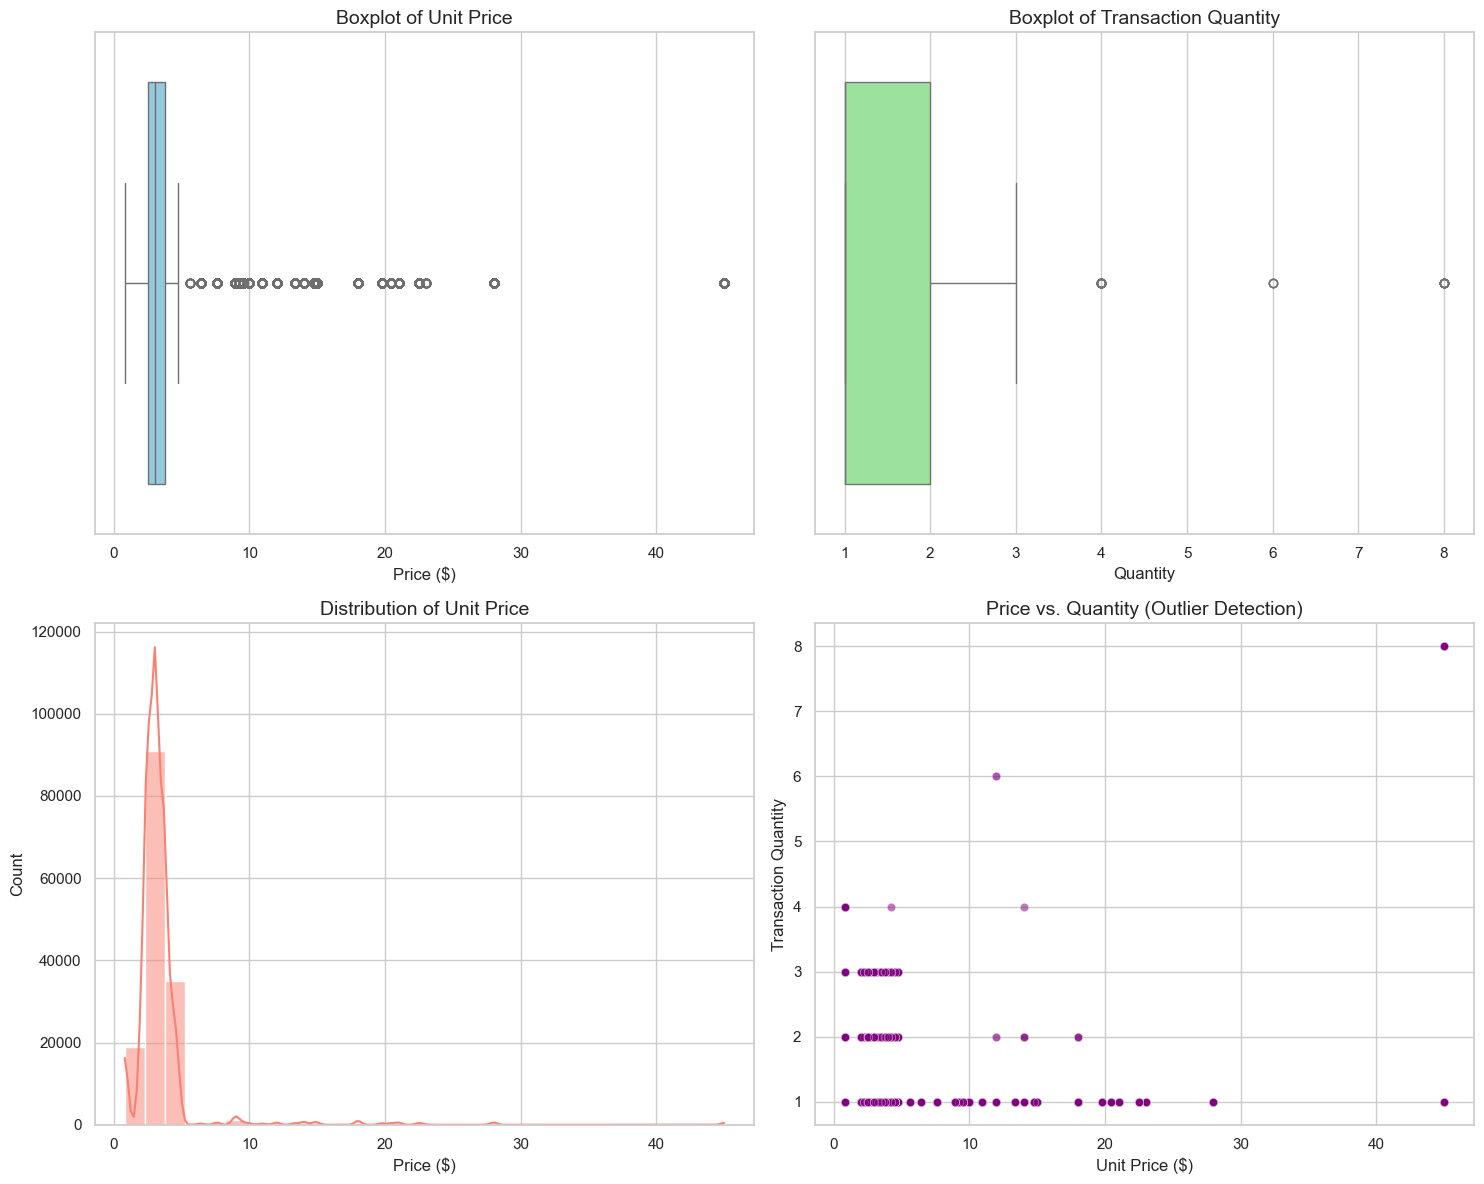

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('Coffee Shop Sales.csv')

# Set aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Boxplot for Unit Price
sns.boxplot(x=df['unit_price'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Boxplot of Unit Price', fontsize=14)
axes[0, 0].set_xlabel('Price ($)')

# 2. Boxplot for Transaction Quantity
sns.boxplot(x=df['transaction_qty'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Boxplot of Transaction Quantity', fontsize=14)
axes[0, 1].set_xlabel('Quantity')

# 3. Histogram/Distribution of Unit Price
sns.histplot(df['unit_price'], bins=30, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution of Unit Price', fontsize=14)
axes[1, 0].set_xlabel('Price ($)')

# 4. Scatter Plot: Price vs Quantity
# Using sample for scatter to avoid overplotting if dataset is huge, but 149k is manageable for a clear visual trend
sns.scatterplot(data=df, x='unit_price', y='transaction_qty', alpha=0.3, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Price vs. Quantity (Outlier Detection)', fontsize=14)
axes[1, 1].set_xlabel('Unit Price ($)')
axes[1, 1].set_ylabel('Transaction Quantity')

plt.tight_layout()
plt.savefig('outlier_analysis.png')

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing for all blocks
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['day_of_week'] = df['transaction_date'].dt.day_name()
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

def get_shift(hour):
    if 6 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    else: return 'Evening'

df['shift'] = df['hour'].apply(get_shift)

C:\Users\mark ando\AppData\Local\Temp\ipykernel_22556\4221199374.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('store_location')['transaction_qty'].sum().reset_index(),
C:\Users\mark ando\AppData\Local\Temp\ipykernel_22556\4221199374.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('day_of_week')['transaction_qty'].sum().reindex(days).reset_index(),
C:\Users\mark ando\AppData\Local\Temp\ipykernel_22556\4221199374.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('shift')['transacti

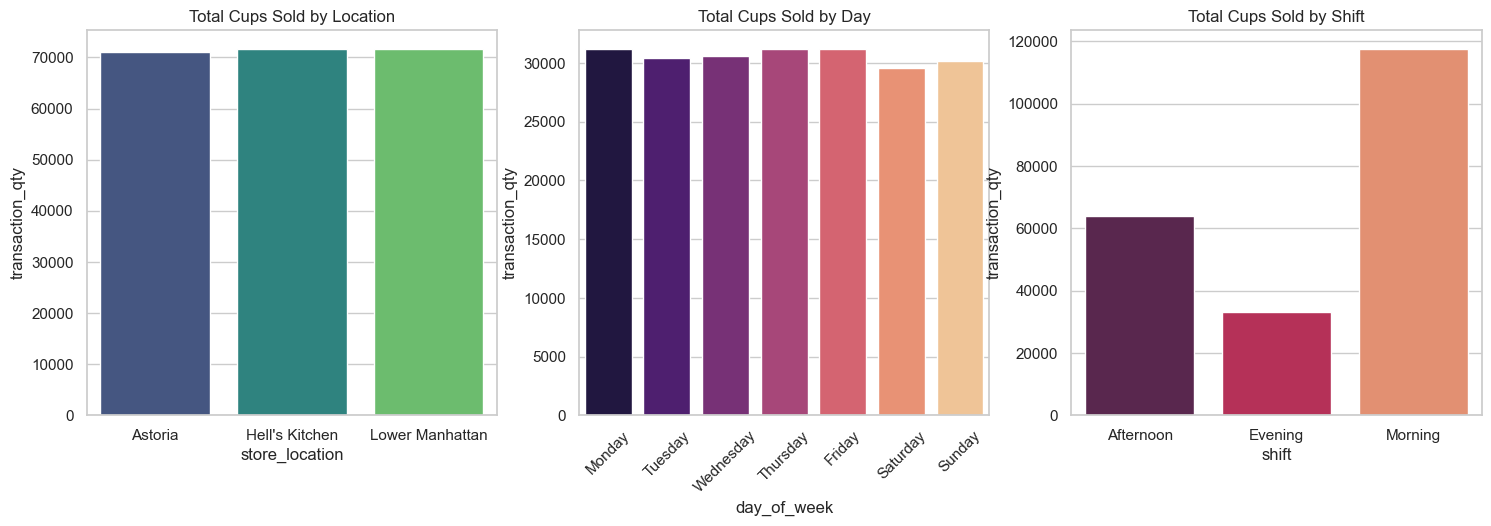

In [24]:
plt.figure(figsize=(18, 5))

# Plot: Sales by Location
plt.subplot(1, 3, 1)
sns.barplot(data=df.groupby('store_location')['transaction_qty'].sum().reset_index(), 
            x='store_location', y='transaction_qty', palette='viridis')
plt.title('Total Cups Sold by Location')

# Plot: Sales by Day (Sorted)
plt.subplot(1, 3, 2)
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df.groupby('day_of_week')['transaction_qty'].sum().reindex(days).reset_index(), 
            x='day_of_week', y='transaction_qty', palette='magma')
plt.title('Total Cups Sold by Day')
plt.xticks(rotation=45)

# Plot: Sales by Shift
plt.subplot(1, 3, 3)
sns.barplot(data=df.groupby('shift')['transaction_qty'].sum().reset_index(), 
            x='shift', y='transaction_qty', palette='rocket')
plt.title('Total Cups Sold by Shift')
plt.show()

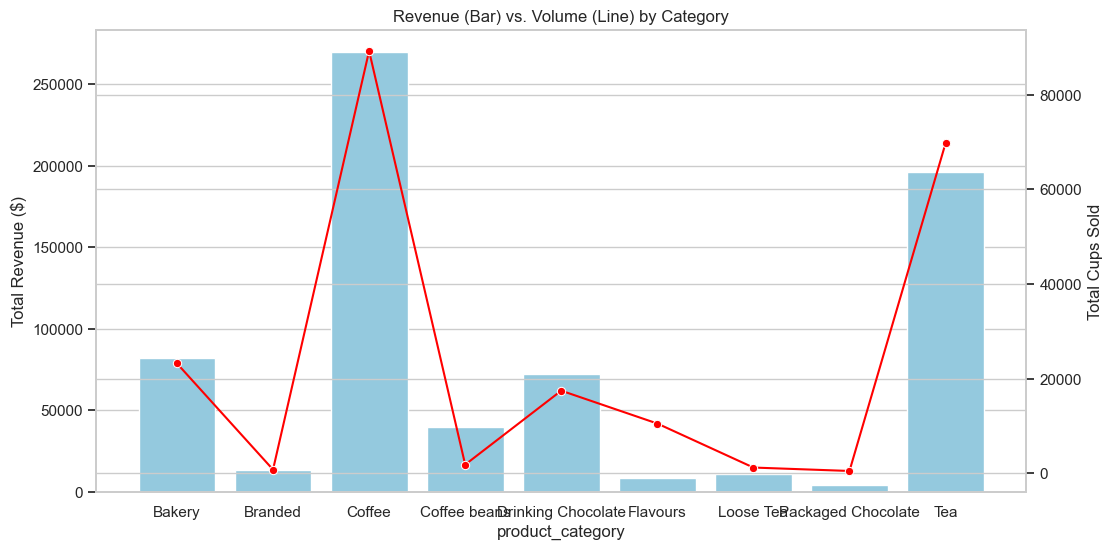

In [26]:
# Calculate Revenue
df['revenue'] = df['transaction_qty'] * df['unit_price']

# Grouping by category
metrics = df.groupby('product_category').agg({'revenue': 'sum', 'transaction_qty': 'sum'}).reset_index()

plt.figure(figsize=(12, 6))
ax1 = sns.barplot(data=metrics, x='product_category', y='revenue', color='skyblue')
ax2 = ax1.twinx()
sns.lineplot(data=metrics, x='product_category', y='transaction_qty', color='red', marker='o', ax=ax2)

ax1.set_ylabel('Total Revenue ($)')
ax2.set_ylabel('Total Cups Sold')
plt.title('Revenue (Bar) vs. Volume (Line) by Category')
plt.xticks(rotation=45)
plt.show()

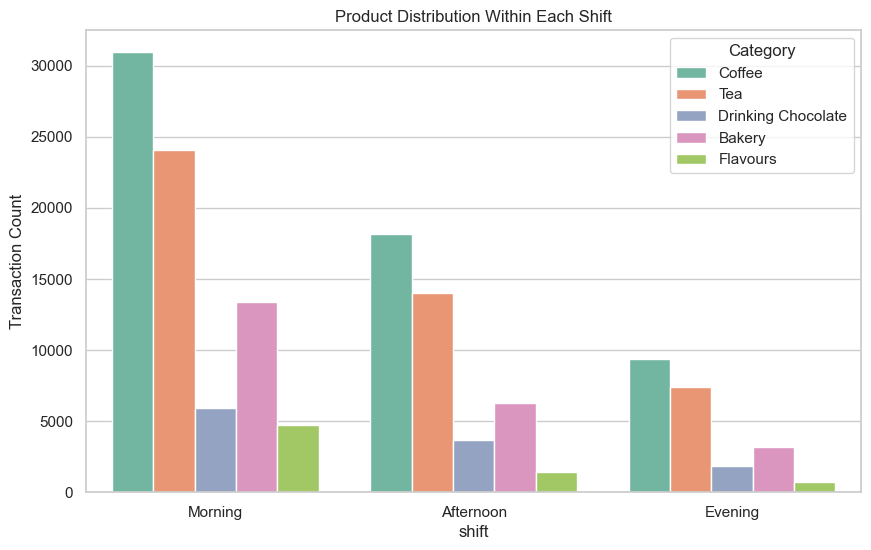

In [28]:
# Focus on Top 5 categories for clarity
top_cats = df['product_category'].value_counts().nlargest(5).index
df_filtered = df[df['product_category'].isin(top_cats)]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x='shift', hue='product_category', palette='Set2')
plt.title('Product Distribution Within Each Shift')
plt.ylabel('Transaction Count')
plt.legend(title='Category', bbox_to_anchor=(1, 1))
plt.show()

C:\Users\mark ando\AppData\Local\Temp\ipykernel_22556\20322250.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='product_type', order=type_order, palette='viridis')


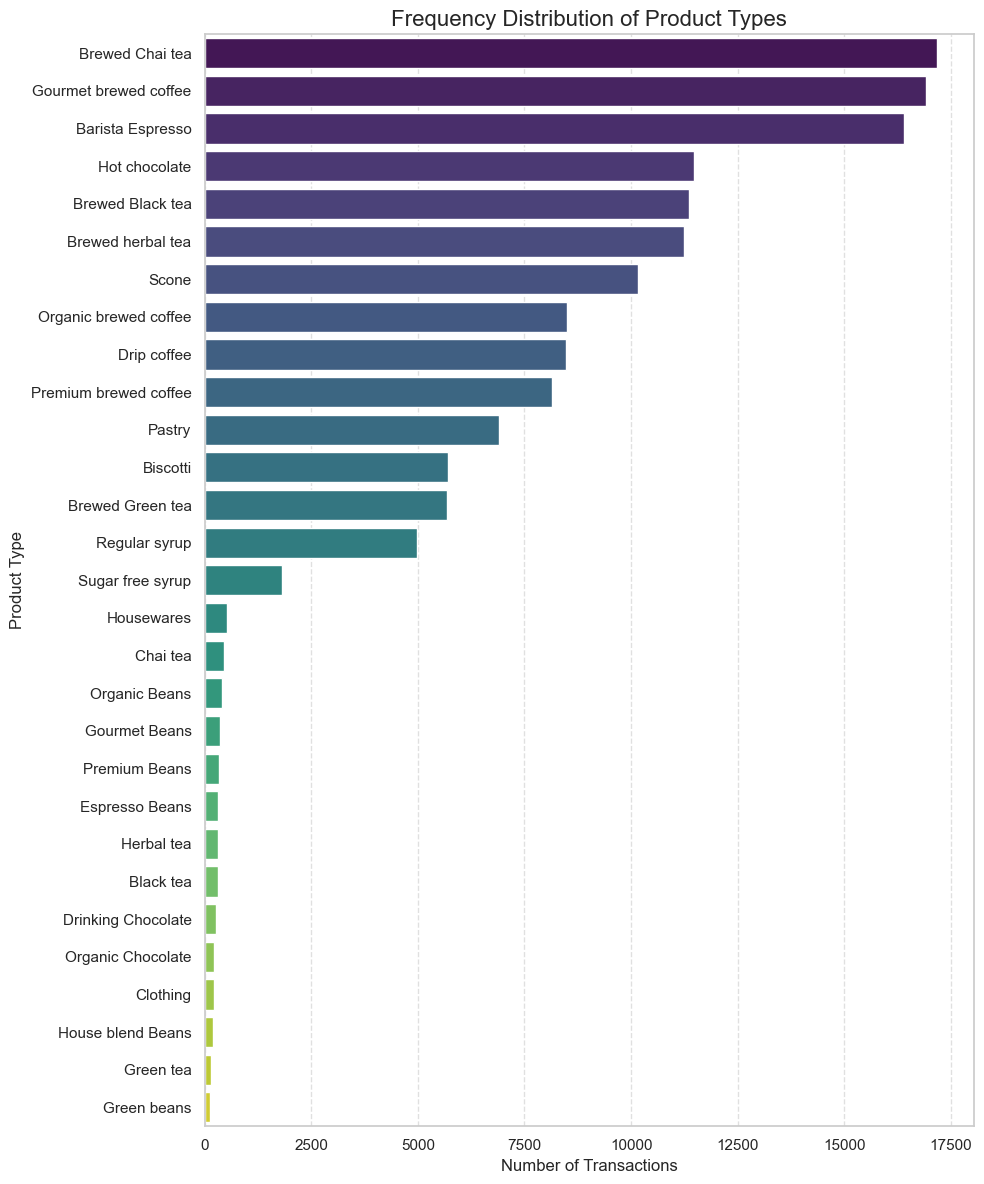

In [30]:
# Set figure size for 29 categories
plt.figure(figsize=(10, 12))

# Get order of product types by frequency
type_order = df['product_type'].value_counts().index

# Create horizontal count plot
sns.countplot(data=df, y='product_type', order=type_order, palette='viridis')

plt.title('Frequency Distribution of Product Types', fontsize=16)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Product Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [32]:
shift_pivot = pd.crosstab(df['product_type'], df['shift'], normalize='index') * 100
print(shift_pivot[['Morning', 'Afternoon', 'Evening']].head(10))

shift                 Morning  Afternoon    Evening
product_type                                       
Barista Espresso    54.136438  30.189599  15.673962
Biscotti            56.329890  28.628962  15.041149
Black tea           62.046205  20.462046  17.491749
Brewed Black tea    53.074890  30.317181  16.607930
Brewed Chai tea     52.359891  31.327475  16.312635
Brewed Green tea    53.006524  30.876389  16.117087
Brewed herbal tea   53.472655  30.706981  15.820365
Chai tea            65.237020  23.702032  11.060948
Clothing            62.895928  25.339367  11.764706
Drinking Chocolate  70.676692  18.045113  11.278195


In [35]:
# --- DATA PREPARATION ---
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

def get_shift(hour):
    if 6 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    else: return 'Evening'

df['shift'] = df['hour'].apply(get_shift)

# Get Top 10 product types to keep the visuals clean
top_10_types = df['product_type'].value_counts().nlargest(10).index
df_top = df[df['product_type'].isin(top_10_types)]

shift                    Morning  Afternoon    Evening
product_type                                          
Barista Espresso       54.136438  30.189599  15.673962
Brewed Black tea       53.074890  30.317181  16.607930
Brewed Chai tea        52.359891  31.327475  16.312635
Brewed herbal tea      53.472655  30.706981  15.820365
Drip coffee            52.259054  30.942550  16.798396
Gourmet brewed coffee  52.276490  31.876774  15.846736
Hot chocolate          51.927101  31.731775  16.341123
Organic brewed coffee  52.833078  30.934150  16.232772
Premium brewed coffee  52.882606  31.358328  15.759066
Scone                  56.581146  29.263737  14.155116

Heatmap saved as product_type_by_shift_heatmap.png


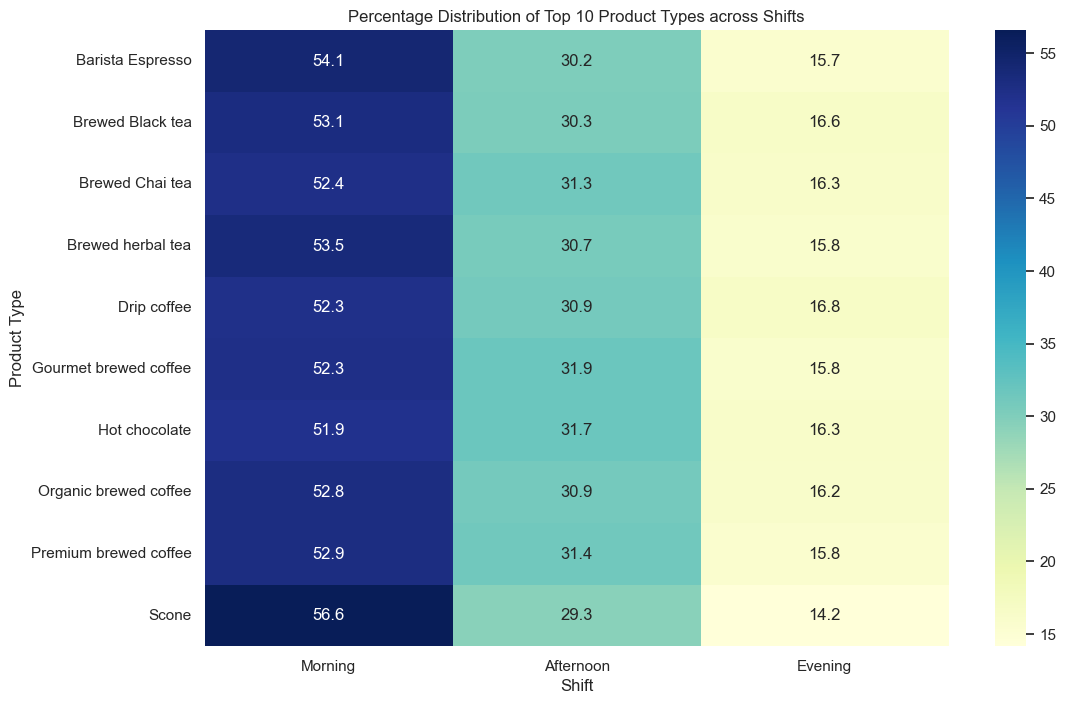

In [37]:
shift_pivot = pd.crosstab(df_top['product_type'], df_top['shift'], normalize='index') * 100
# Reorder shifts logically
shift_pivot = shift_pivot[['Morning', 'Afternoon', 'Evening']]
print(shift_pivot)

plt.figure(figsize=(12, 8))
sns.heatmap(shift_pivot, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title('Percentage Distribution of Top 10 Product Types across Shifts')
plt.xlabel('Shift')
plt.ylabel('Product Type')
plt.savefig('product_type_by_shift_heatmap.png')
print("\nHeatmap saved as product_type_by_shift_heatmap.png")

Monthly trend plot saved as product_type_monthly_trend.png


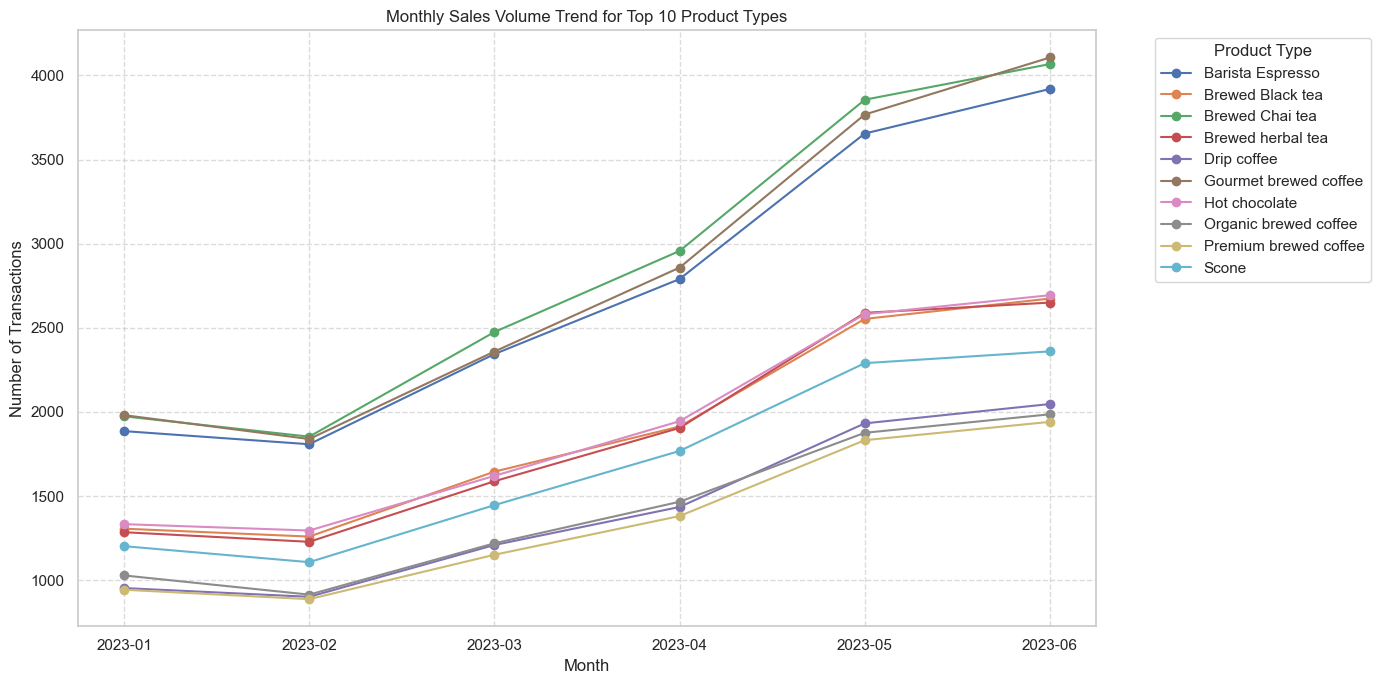

In [39]:
# Extract month for a smoother trend line
df_top['month'] = df_top['transaction_date'].dt.to_period('M').astype(str)
monthly_trends = df_top.groupby(['month', 'product_type']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
monthly_trends.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Monthly Sales Volume Trend for Top 10 Product Types')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.legend(title='Product Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('product_type_monthly_trend.png')
print("Monthly trend plot saved as product_type_monthly_trend.png")

In [41]:
top_5_types = top_10_types[:5]
for p_type in top_5_types:
    peak_hour = df[df['product_type'] == p_type]['hour'].mode()[0]
    print(f"Peak hour for {p_type}: {peak_hour}:00")

Peak hour for Brewed Chai tea: 10:00
Peak hour for Gourmet brewed coffee: 10:00
Peak hour for Barista Espresso: 10:00
Peak hour for Hot chocolate: 10:00
Peak hour for Brewed Black tea: 9:00


Text(0.5, 1.0, 'The Core Logic: How Cups Predict Revenue per Store')

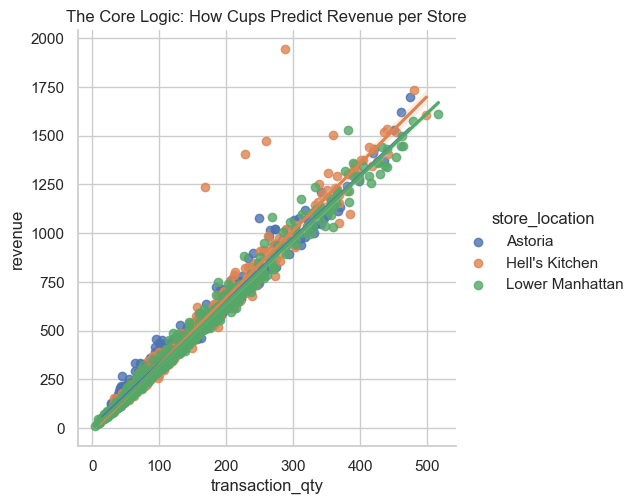

In [45]:
# Create the actual "Model-Ready" aggregation for EDA
model_eda = df.groupby(['transaction_date', 'store_location', 'shift']).agg({
    'transaction_qty': 'sum',
    'revenue': 'sum'
}).reset_index()

# Plot the most important graph for your Model 2:
sns.lmplot(data=model_eda, x='transaction_qty', y='revenue', hue='store_location')
plt.title("The Core Logic: How Cups Predict Revenue per Store")

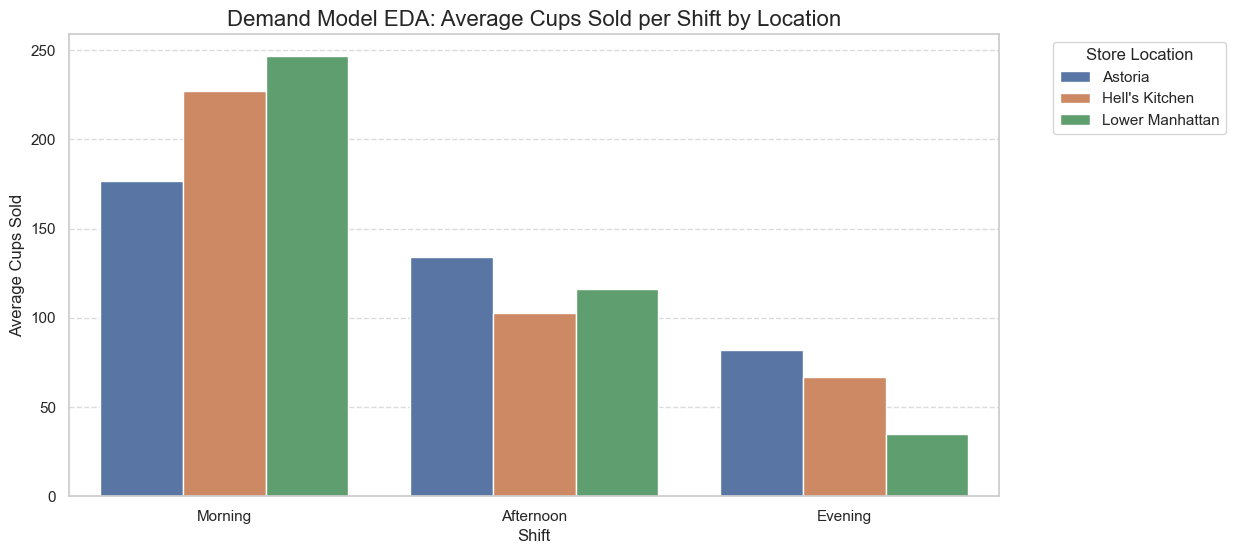

In [47]:
# Preprocessing: Convert dates and times
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

# Define logical shift function
def get_shift(hour):
    if 6 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    else: return 'Evening'

df['shift'] = df['hour'].apply(get_shift)

# Aggregate: Total Cups Sold per Shift per Day per Location
aggregated_df = df.groupby(['transaction_date', 'store_location', 'shift'])['transaction_qty'].sum().reset_index()

# Map shifts to a numeric order for correct plotting
shift_order = ['Morning', 'Afternoon', 'Evening']
aggregated_df['shift'] = pd.Categorical(aggregated_df['shift'], categories=shift_order, ordered=True)

# Plotting: Average Cups Sold per Shift across different locations
plt.figure(figsize=(12, 6))
sns.barplot(data=aggregated_df, x='shift', y='transaction_qty', hue='store_location', errorbar=None)

plt.title('Demand Model EDA: Average Cups Sold per Shift by Location', fontsize=16)
plt.ylabel('Average Cups Sold', fontsize=12)
plt.xlabel('Shift', fontsize=12)
plt.legend(title='Store Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

Top 20 Product Type Distribution Data (Percentages):
product_type  Barista Espresso  Biscotti  Brewed Black tea  Brewed Chai tea  \
shift                                                                         
Morning              11.054263  4.004681          7.498973        11.199910   
Afternoon            11.254290  3.715825          7.820277        12.233813   
Evening              11.339479  3.788647          8.313853        12.362722   

product_type  Brewed Green tea  Brewed herbal tea  Chai tea  Drip coffee  \
shift                                                                      
Morning               3.742017           7.485280  0.359761     5.514683   
Afternoon             3.979455           7.847549  0.238631     5.961228   
Evening               4.031227           7.846337  0.216116     6.280598   

product_type  Gourmet Beans  Gourmet brewed coffee  
shift                                               
Morning            0.288805              11.005714  
Afternoon  

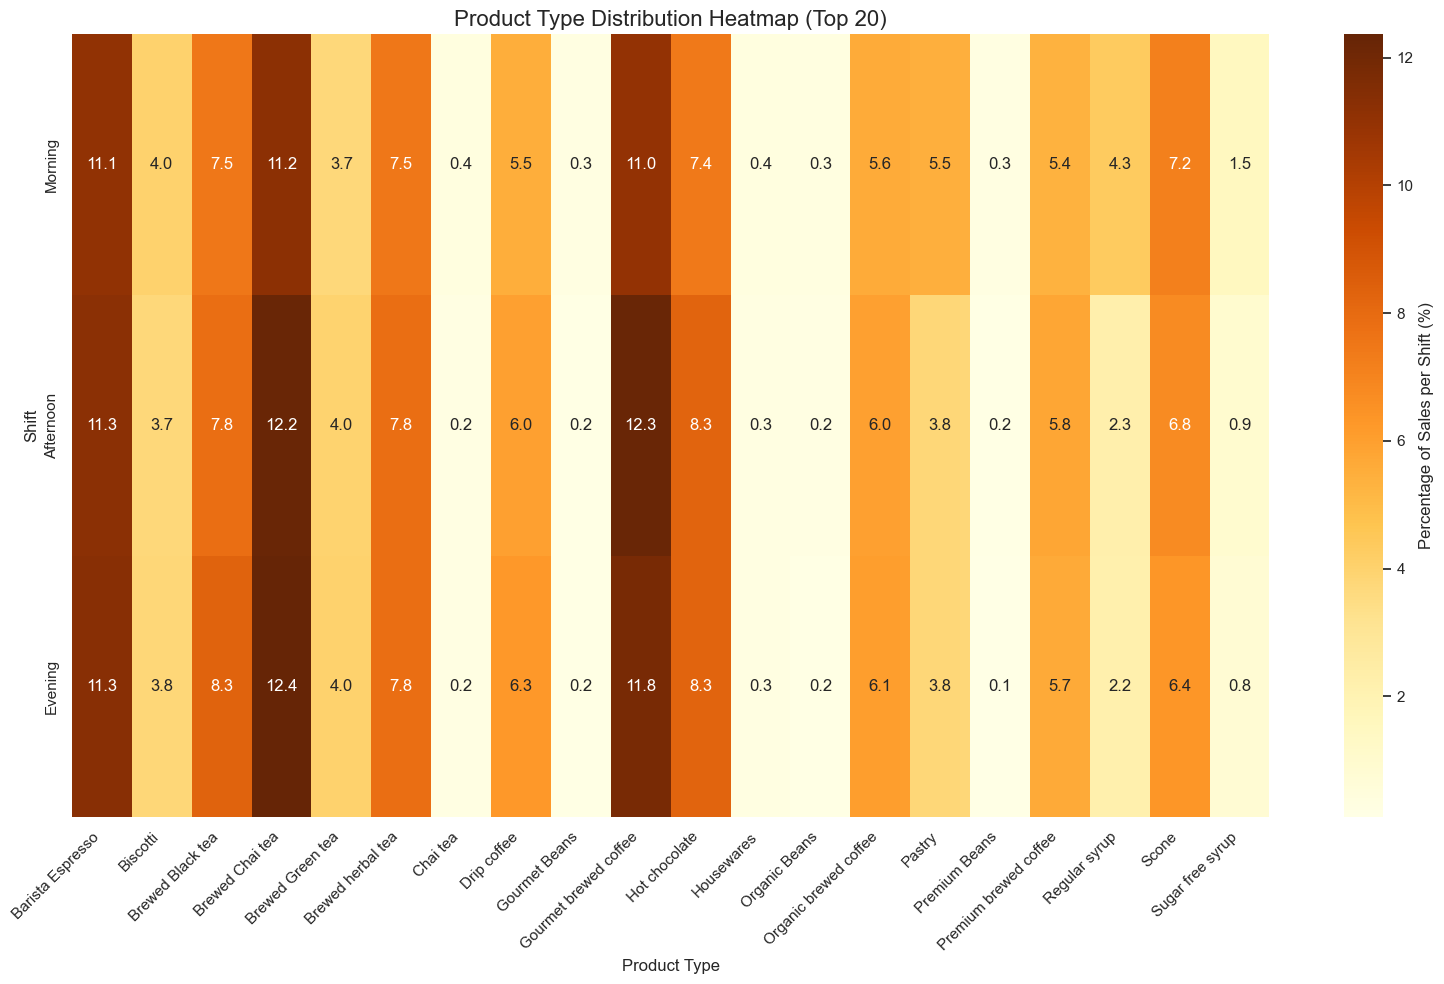

In [49]:
top_types = df['product_type'].value_counts().nlargest(20).index
df_filtered = df[df['product_type'].isin(top_types)]

# 3. Create Distribution Data
type_dist = pd.crosstab(df_filtered['shift'], df_filtered['product_type'], normalize='index') * 100

# 4. Sort Shifts Chronologically
shift_order = ['Morning', 'Afternoon', 'Evening']
type_dist = type_dist.reindex(shift_order)

# 5. Visualization
plt.figure(figsize=(16, 10))
sns.heatmap(type_dist, annot=True, cmap="YlOrBr", fmt=".1f", cbar_kws={'label': 'Percentage of Sales per Shift (%)'})
plt.title('Product Type Distribution Heatmap (Top 20)', fontsize=16)
plt.ylabel('Shift', fontsize=12)
plt.xlabel('Product Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('product_type_distribution_heatmap.png')

print("Top 20 Product Type Distribution Data (Percentages):")
print(type_dist.iloc[:, :10]) # Displaying first 10 for brevity in log